In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster  import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from retail_data import generate_retail_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

1. Load Retail Dataset

In [6]:
df = generate_retail_dataset(n_samples=2000, random_state=RANDOM_STATE)
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 7)


,Age,Annual_Income,Spending_Score,Num_Purchases,Avg_Transaction_Value,Total_Sales,Customer_Segment
0,56,81788,1,15,137,2055,Medium Value
1,69,102879,36,27,253,6831,High Value
2,46,58827,35,13,65,845,High Value
3,32,25655,66,49,200,9800,Medium Value
4,60,64859,63,31,985,30535,Low Value


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Age                    2000 non-null   int32
 1   Annual_Income          2000 non-null   int32
 2   Spending_Score         2000 non-null   int32
 3   Num_Purchases          2000 non-null   int32
 4   Avg_Transaction_Value  2000 non-null   int32
 5   Total_Sales            2000 non-null   int32
 6   Customer_Segment       2000 non-null   str  
dtypes: int32(6), str(1)
memory usage: 82.8 KB


,Age,Annual_Income,Spending_Score,Num_Purchases,Avg_Transaction_Value,Total_Sales
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,43.805500,69366.908000,50.803500,24.86150,523.511000,13004.929000
std,14.929203,28876.508855,28.212743,13.98657,275.071245,10632.557722
min,18.000000,20138.000000,1.000000,1.00000,50.000000,50.000000
25%,31.000000,44523.500000,27.000000,13.00000,280.000000,4291.500000
50%,44.000000,69156.000000,52.000000,24.00000,527.000000,10296.000000
75%,56.000000,94531.750000,75.000000,37.00000,757.250000,19263.000000
max,69.000000,119983.000000,99.000000,49.00000,999.000000,47232.000000


2. Exploratory Data Analysis

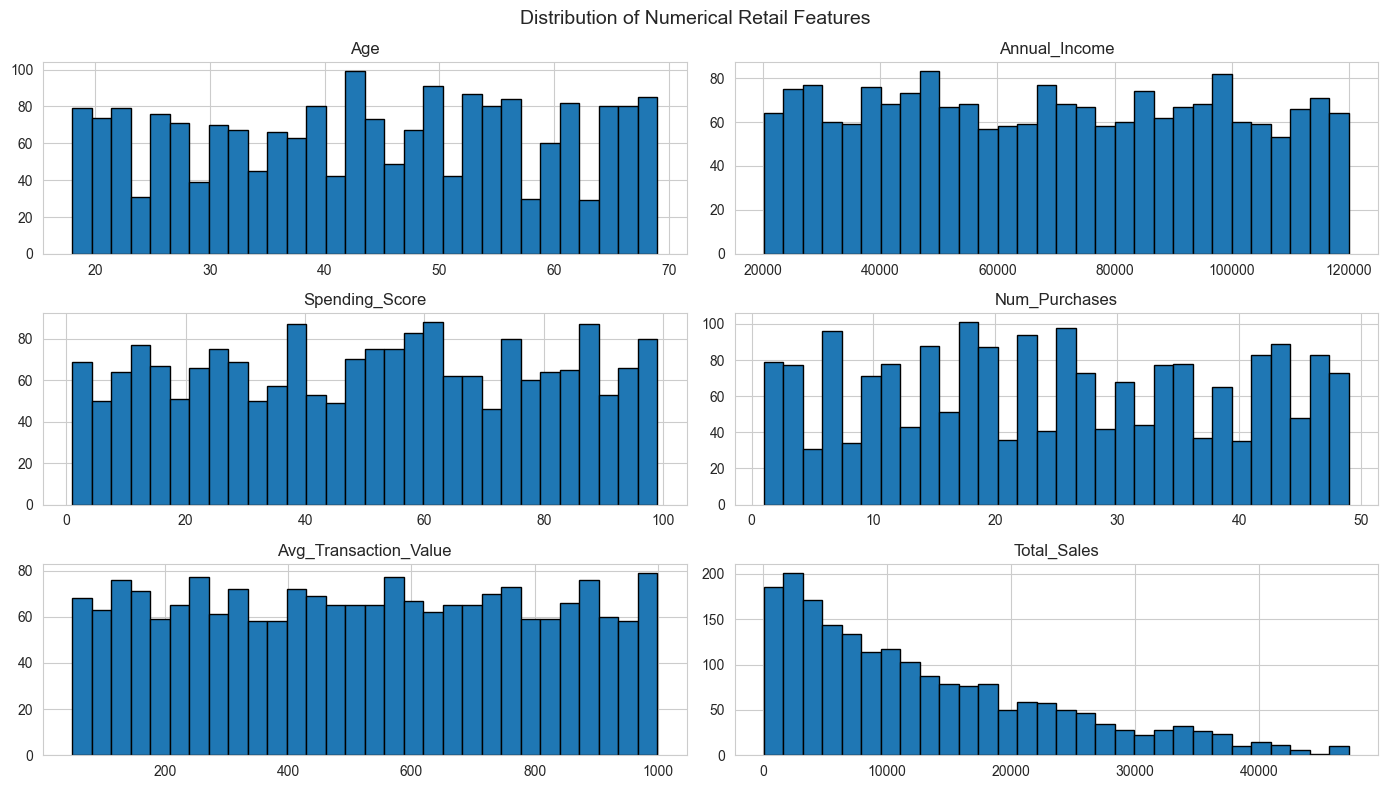

In [ ]:
numerical_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value', 'Total_Sales']
df[numerical_cols].hist(bins=30, figsize=(14, 8), edgecolor='black')
plt.suptitle('Distribution of Numerical Retail Features', fontsize=14)
plt.tight_layout()
# plt.show()     ##and creates histograms for each column.

# Histogram

# A histogram shows how data values are distributed.

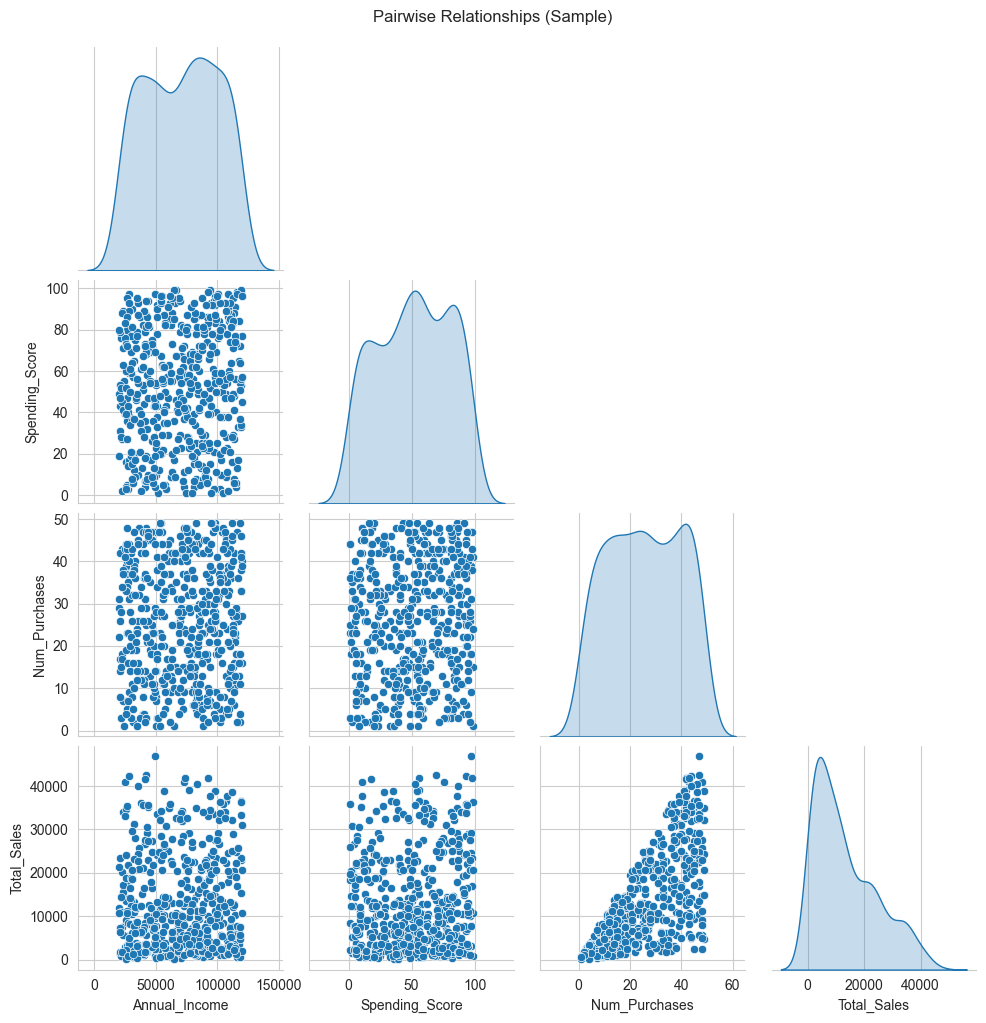

In [ ]:
sns.pairplot(df[['Annual_Income', 'Spending_Score', 'Num_Purchases', 'Total_Sales']].sample(500, random_state=RANDOM_STATE),
             diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships (Sample)', y=1.02)
plt.show()
##This code creates a Pair Plot, which is used during Exploratory Data Analysis (EDA) 
# to understand relationships between multiple numerical features.

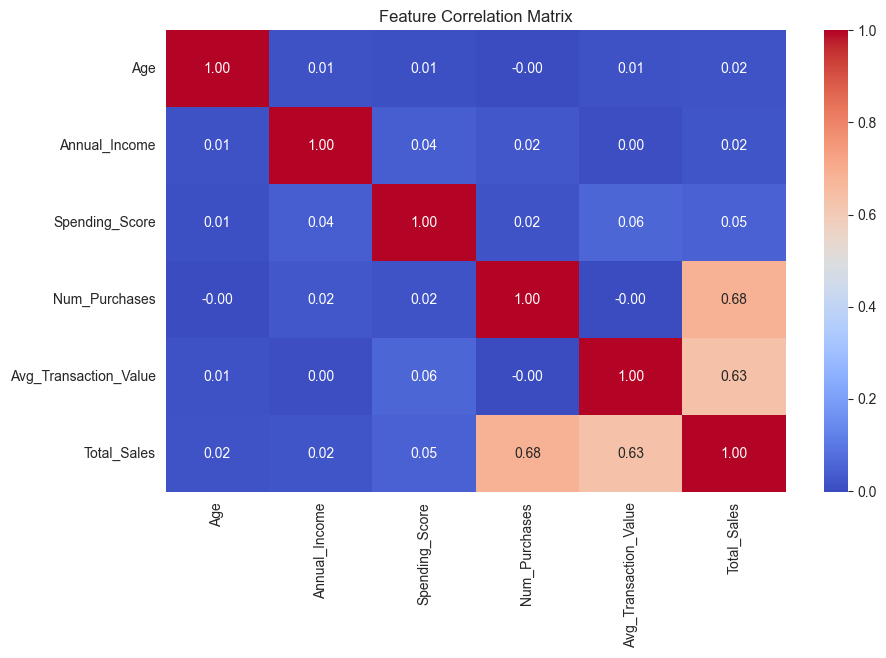

In [ ]:
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()
# ##🔴 Red = Positive Correlation

# 🔵 Blue = Negative Correlation

# ⚪ White = Near Zero Correlation

3. Feature Selection & Preprocessing

K-Means works on numerical features. We select behavioral and demographic variables and scale them.

In [ ]:
feature_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features used: {feature_cols}')
print(f'Scaled shape: {X_scaled.shape}')

Features used: ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']
Scaled shape: (2000, 5)
Features used: ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']


4. Find Optimal K (Elbow & Silhouette)

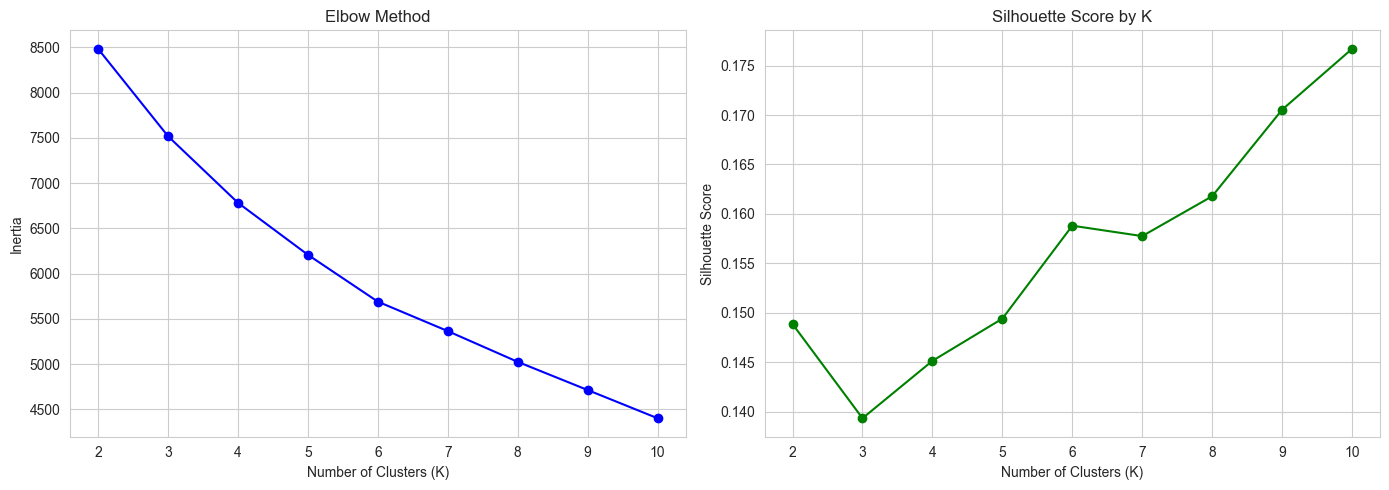

Optimal K (by silhouette): 10


In [13]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouettes)]
print(f'Optimal K (by silhouette): {optimal_k}')
     

5. Train Final K-Means Model

In [14]:
OPTIMAL_K = optimal_k
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nSilhouette Score: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(f'Davies-Bouldin Index: {davies_bouldin_score(X_scaled, df["Cluster"]):.4f}')
print(f'Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, df["Cluster"]):.4f}')

Cluster distribution:
Cluster
0    205
1    192
2    195
3    197
4    214
5    189
6    207
7    186
8    189
9    226
Name: count, dtype: int64

Silhouette Score: 0.1767
Davies-Bouldin Index: 1.2963
Calinski-Harabasz Score: 281.2066


6. Visualize Clusters

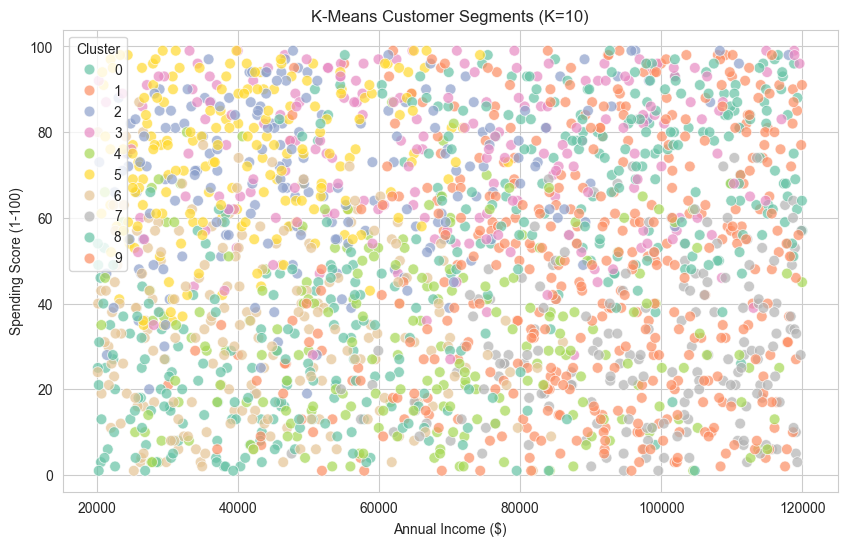

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette='Set2', s=60, alpha=0.7)
plt.title(f'K-Means Customer Segments (K={OPTIMAL_K})')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()


# 🟢 High Income – High Spending

# → Premium customers

# 🔵 High Income – Low Spending

# → Savings-focused customers

# 🟠 Low Income – High Spending

# → Impulsive buyers

# 🔴 Low Income – Low Spending

# → Budget customers

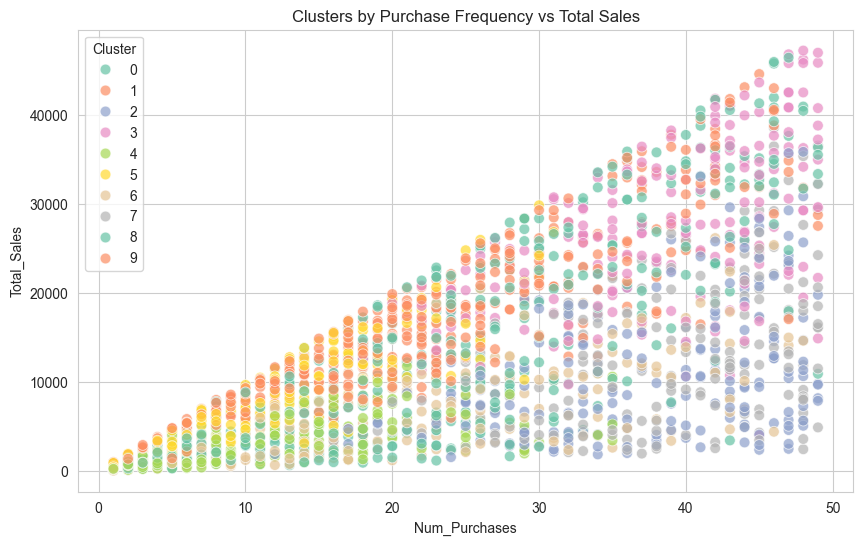

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Num_Purchases', y='Total_Sales', hue='Cluster', palette='Set2', s=60, alpha=0.7)
plt.title('Clusters by Purchase Frequency vs Total Sales')
plt.show()

7. Cluster Profiling

In [17]:
cluster_profile = df.groupby('Cluster')[feature_cols + ['Total_Sales']].mean().round(2)
cluster_profile
     

,Age,Annual_Income,Spending_Score,Num_Purchases,Avg_Transaction_Value,Total_Sales
Cluster,,,,,,
0,52.38,94275.26,73.70,15.69,337.54,4792.04
1,54.05,84876.24,23.82,17.06,752.36,12849.39
2,32.62,53059.16,70.10,37.13,299.64,11271.95
3,57.26,69640.57,75.02,38.26,718.28,27331.66
4,29.22,67180.09,32.15,11.99,307.49,3435.29
5,44.88,41130.05,74.10,12.07,711.21,8650.63
6,57.88,43533.33,33.66,21.79,300.93,6705.24
7,46.94,97068.90,29.68,38.56,335.18,13201.06
8,34.81,45449.03,24.65,32.93,745.99,24256.28


In [18]:
segment_crosstab = pd.crosstab(df['Cluster'], df['Customer_Segment'], normalize='index').round(3)
print('Cluster vs Actual Customer Segment (proportion):')
segment_crosstab
     

Cluster vs Actual Customer Segment (proportion):


Customer_Segment,High Value,Low Value,Medium Value
Cluster,,,
0,0.307,0.322,0.371
1,0.344,0.323,0.333
2,0.333,0.349,0.318
3,0.299,0.355,0.345
4,0.318,0.364,0.318
5,0.333,0.354,0.312
6,0.290,0.415,0.295
7,0.312,0.339,0.349
8,0.339,0.307,0.354
